# Observe analysis windows of interest

In [1]:
import os
import pandas as pd
import numpy as np
from typing import Optional
# Antigen tools
import sys
sys.path.append('..')
from antigentools.plot import (
    plot_analysis_window, 
    plot_analysis_window_with_variant_counts,
    plot_r_model,
    plot_r_data,
    plot_smoothed_variant_counts,
    plot_growth_rate_dynamics
)
from antigentools.utils import calculate_empirical_growth_rate_EL
from scipy.stats import gamma, pearsonr
from scipy.interpolate import UnivariateSpline, interp1d
import matplotlib.pyplot as plt
import seaborn as sns

/Users/zthornto/miniforge3/envs/antigen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helper functions to later be moved into `antigentools`

In [2]:
def load_model_rt_values(build: str, model: str, location: str, pivot_date: str) -> Optional[pd.DataFrame]:
    """
    Load Rt values directly from model result files.
    
    Parameters:
    -----------
    build : str
        The build name (e.g., 'flu-simulated-150k-samples').
    model : str
        The model name (e.g., 'FGA', 'GARW').
    location : str
        The location name (e.g., 'north', 'tropics').
    pivot_date : str
        The pivot date in YYYY-MM-DD format.
    
    Returns:
    --------
    Optional[pd.DataFrame]
        A DataFrame containing the Rt values, or None if the file is not found.
    """
    # Construct path to the Rt file for this model, location, and date
    rt_path = f"../results/{build}/estimates/{model}/rt_{location}_{pivot_date}.tsv"
    
    try:
        # Read the file
        rt_df = pd.read_csv(rt_path, sep='\t')
        print(f"Loaded {len(rt_df)} Rt values from {rt_path}")
        return rt_df
    except FileNotFoundError:
        print(f"Could not find Rt file: {rt_path}")
        return None

In [3]:
def convert_rt_to_growth_rate(rt_df: pd.DataFrame, gamma_shape: float = 2.5, gamma_scale: float = 1.5, rt_column: str = 'median_R') -> pd.DataFrame:
    """
    Convert reproduction numbers (Rt) to growth rates (r) using the Euler-Lotka equation.
    
    Parameters:
    -----------
    rt_df : pd.DataFrame
        DataFrame containing Rt values loaded from model result files.
    gamma_shape : float, default=2.5
        Shape parameter k for the gamma distribution of generation time.
    gamma_scale : float, default=1.5
        Scale parameter θ for the gamma distribution of generation time.
    rt_column : str, default='median_R'
        Name of the column in rt_df containing the Rt values.
    
    Returns:
    --------
    pd.DataFrame
        A copy of the input DataFrame with an additional 'growth_rate_r' column.
    """
    # Create a copy of the input DataFrame to avoid modifying the original
    result_df = rt_df.copy()
    
    # Apply the Euler-Lotka equation: r = (Rt^(1/k) - 1) / θ
    result_df['growth_rate_r'] = (result_df[rt_column]**(1.0/gamma_shape) - 1.0) / gamma_scale
    
    return result_df

In [4]:
def smooth_with_spline(
    df: pd.DataFrame, 
    col_to_smooth: str = 'sequences',
    output_col: str = 'smoothed_sequences',
    s: float = 0.5, 
    k: int = 3,
    log_transform: bool = False
) -> pd.DataFrame:
    """
    Smooth variant sequence counts using 1-D spline fitting.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing sequence counts data with columns 'country', 'variant', 
        'date', and `col_to_smooth`.
    col_to_smooth : str, default='sequences'
        The name of the column containing the sequence counts to be smoothed.
    output_col : str, default='smoothed_sequences'
        The name of the column to store the smoothed sequence counts.
    log_transform : bool, default=True
        If True, applies log1p transformation to the sequence counts before smoothing.
        This can help stabilize variance for highly skewed data, and counts.
    s : float, default=0.5
        Positive smoothing factor. Larger values produce smoother curves.
        s=0 forces the spline to interpolate through all data points exactly.
        Recommended range: 0.1-10 depending on noise level.
    k : int, default=3
        Degree of the smoothing spline. Must be 1 <= k <= 5.
        k=3 gives cubic splines which are generally smooth and flexible.
    
    Returns:
    --------
    pd.DataFrame
        A copy of the input DataFrame with an additional `output_col` column
        containing the spline-smoothed sequence counts.
    
    Notes:
    ------
    - Higher s values will produce smoother curves but may miss important trends
    - Lower s values will follow the data more closely but may overfit noise
    - For noisy data, s values between 1-5 often work well
    - For cleaner data, s values between 0.1-1 may be more appropriate
    """
    # Validate parameters
    if k < 1 or k > 5:
        raise ValueError("k must be between 1 and 5")
    if s < 0:
        raise ValueError("s must be non-negative")
    
    # Create a copy of the input DataFrame
    result_df = df.copy()
    result_df.dropna(subset=[col_to_smooth], inplace=True)
    
    # Add a column for the smoothed counts, initialize with NaN
    result_df[output_col] = np.nan
    
    # Convert date to datetime
    if not pd.api.types.is_datetime64_any_dtype(result_df['date']):
        result_df['date'] = pd.to_datetime(result_df['date'])
    
    # For each location and variant combination, perform the smoothing
    for location in result_df['country'].unique():
        for variant in result_df[result_df['country'] == location]['variant'].unique():
            # Get data for this specific location and variant
            mask = (result_df['country'] == location) & (result_df['variant'] == variant)
            variant_data = result_df[mask].sort_values('date')
            
            # Skip if we don't have enough data points
            # Need at least k+1 data points for a degree k spline
            if len(variant_data) < k + 1:
                print(f"Skipping smoothing for {location}, variant {variant}: "
                      f"not enough data points ({len(variant_data)})")
                continue
            
            # Create a numerical index for dates (days since first observation)
            variant_data = variant_data.copy()
            variant_data['day_index'] = (variant_data['date'] - variant_data['date'].min()).dt.days
            
            # Apply spline fitting to the sequence counts
            # Convert to 1-indexed arrays for scipy
            x = variant_data['day_index'].values
            y = variant_data[col_to_smooth].values
            
            try:
                # If log_transform is enabled, apply log1p transformation
                if log_transform:
                    y = np.log1p(y)
                
                # Fit spline to log-transformed data
                spline = UnivariateSpline(x, y, k=k, s=s)
                
                # Predict smoothed values for all points
                smoothed_y = spline(x)
                
                if log_transform:
                    smoothed_y = np.expm1(smoothed_y)  # Transform back from log space
                
                # Update the result DataFrame with smoothed values
                result_df.loc[variant_data.index, output_col] = smoothed_y
            
            except Exception as e:
                # If spline fitting fails, fall back to original counts
                print(f"Warning: Spline fitting failed for {location}, variant {variant}: {e}")
                result_df.loc[variant_data.index, output_col] = variant_data[col_to_smooth]
    
    return result_df

In [5]:
def smooth_sequences_with_spline(
    seqs_df: pd.DataFrame, 
    s: float = 0.5, 
    k: int = 3
) -> pd.DataFrame:
    """
    Smooth variant sequence counts using 1-D spline fitting.
    
    This function creates a smoothed version of sequence counts by applying univariate
    spline interpolation to each variant in each location. The smoothing uses scipy's
    UnivariateSpline which fits a B-spline to the data.
    
    Parameters:
    -----------
    seqs_df : pd.DataFrame
        DataFrame containing sequence counts data with columns 'country', 'variant', 
        'date', and 'sequences'.
    s : float, default=0.5
        Positive smoothing factor. Larger values produce smoother curves.
        s=0 forces the spline to interpolate through all data points exactly.
        Recommended range: 0.1-10 depending on noise level.
    k : int, default=3
        Degree of the smoothing spline. Must be 1 <= k <= 5.
        k=3 gives cubic splines which are generally smooth and flexible.
    
    Returns:
    --------
    pd.DataFrame
        A copy of the input DataFrame with an additional 'smoothed_sequences' column
        containing the spline-smoothed sequence counts.
    
    Notes:
    ------
    - Higher s values will produce smoother curves but may miss important trends
    - Lower s values will follow the data more closely but may overfit noise
    - For noisy data, s values between 1-5 often work well
    - For cleaner data, s values between 0.1-1 may be more appropriate
    """
    # Validate parameters
    if k < 1 or k > 5:
        raise ValueError("k must be between 1 and 5")
    if s < 0:
        raise ValueError("s must be non-negative")
    
    # Create a copy of the input DataFrame
    result_df = seqs_df.copy()
    
    # Add a column for the smoothed counts, initialize with NaN
    result_df['smoothed_sequences'] = np.nan
    
    # Convert date to datetime
    if not pd.api.types.is_datetime64_any_dtype(result_df['date']):
        result_df['date'] = pd.to_datetime(result_df['date'])
    
    # For each location and variant combination, perform the smoothing
    for location in result_df['country'].unique():
        for variant in result_df[result_df['country'] == location]['variant'].unique():
            # Get data for this specific location and variant
            mask = (result_df['country'] == location) & (result_df['variant'] == variant)
            variant_data = result_df[mask].sort_values('date')
            
            # Skip if we don't have enough data points
            # Need at least k+1 data points for a degree k spline
            if len(variant_data) < k + 1:
                continue
            
            # Create a numerical index for dates (days since first observation)
            variant_data = variant_data.copy()
            variant_data['day_index'] = (variant_data['date'] - variant_data['date'].min()).dt.days
            
            # Apply spline fitting to the sequence counts
            # Convert to 1-indexed arrays for scipy
            x = variant_data['day_index'].values
            y = variant_data['sequences'].values
            
            try:
                # Apply logarithmic transformation for better behavior with count data
                # Add small constant to avoid log(0)
                log_y = np.log1p(y)
                
                # Fit spline to log-transformed data
                spline = UnivariateSpline(x, log_y, k=k, s=s)
                
                # Predict smoothed values for all points
                smoothed_log_y = spline(x)
                
                # Transform back from log space
                smoothed_y = np.expm1(smoothed_log_y)
                
                # Update the result DataFrame with smoothed values
                result_df.loc[variant_data.index, 'smoothed_sequences'] = smoothed_y
            
            except Exception as e:
                # If spline fitting fails, fall back to original counts
                print(f"Warning: Spline fitting failed for {location}, variant {variant}: {e}")
                result_df.loc[variant_data.index, 'smoothed_sequences'] = variant_data['sequences']
    
    return result_df

In [6]:
def add_week_id_column(df: pd.DataFrame, date_col: str = 'date') -> pd.DataFrame:
    """
    Add a week_id column to a dataframe that represents the chronological order of dates.
    
    This function creates a new column 'week_id' that assigns a unique integer ID
    to each unique date in the dataframe, with earlier dates receiving smaller IDs.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing a date column
    date_col : str, default='date'
        Name of the column containing date information
        
    Returns:
    --------
    pd.DataFrame
        A copy of the input DataFrame with an additional 'week_id' column
        
    Notes:
    ------
    - The function ensures that dates are properly sorted chronologically
    - All rows with the same date will receive the same week_id
    - The earliest date will have week_id=0
    """
    # Create a copy of the dataframe to avoid modifying the original
    result_df = df.copy()
    
    # Ensure date column is datetime type
    if not pd.api.types.is_datetime64_any_dtype(result_df[date_col]):
        result_df[date_col] = pd.to_datetime(result_df[date_col])
    
    # Get unique dates and sort them chronologically
    unique_dates = sorted(result_df[date_col].unique())
    
    # Create a mapping from date to week_id
    date_to_id = {date: i for i, date in enumerate(unique_dates)}
    
    # Add the week_id column based on the mapping
    result_df['week_id'] = result_df[date_col].map(date_to_id)
    
    return result_df

In [7]:
def add_variant_frequencies(seqs_df: pd.DataFrame, count_column: str = 'smoothed_sequences') -> pd.DataFrame:
    """
    Calculate and add variant frequencies to the dataframe.
    
    This function takes a dataframe containing variant sequence counts and adds a new column
    with the relative frequency of each variant at each location and time point.
    
    Parameters:
    -----------
    seqs_df : pd.DataFrame
        DataFrame containing sequence data with 'country', 'variant', 'date',
        and sequence count columns.
    count_column : str, default='smoothed_sequences'
        Name of the column containing sequence counts to use for frequency calculation.
        Could be raw 'sequences' or 'smoothed_sequences'.
    
    Returns:
    --------
    pd.DataFrame
        A copy of the input DataFrame with an additional 'variant_frequency' column
        containing the relative frequency of each variant.
    
    Notes:
    ------
    - If a location and date combination has no sequences at all, frequencies will be NaN
    - Frequencies for each location and date should sum to 1.0
    - NaN values in the count column will be excluded from frequency calculations
    """
    # Create a copy of the input DataFrame
    result_df = seqs_df.copy()
    
    # Add a column for the variant frequencies, initialize with NaN
    result_df['variant_frequency'] = np.nan
    
    # Ensure date is in datetime format
    if not pd.api.types.is_datetime64_any_dtype(result_df['date']):
        result_df['date'] = pd.to_datetime(result_df['date'])
    
    # Calculate the total counts for each location and date
    total_counts = result_df.groupby(['country', 'date'])[count_column].transform('sum')
    
    # Calculate the variant frequency as the proportion of each variant
    result_df['variant_frequency'] = result_df[count_column] / total_counts
    
    # Validate frequencies (should sum to 1.0 for each location and date)
    # Group by location and date, and check the sum of frequencies
    freq_sums = result_df.groupby(['country', 'date'])['variant_frequency'].sum().reset_index()
    freq_sums = freq_sums.rename(columns={'variant_frequency': 'freq_sum'})
    
    # Check if any sum deviates significantly from 1.0
    validation_threshold = 0.01  # Allow 1% deviation due to floating point errors
    invalid_sums = freq_sums[(abs(freq_sums['freq_sum'] - 1.0) > validation_threshold) & 
                            (~freq_sums['freq_sum'].isna())]
    
    if len(invalid_sums) > 0:
        print(f"Warning: {len(invalid_sums)} location-date combinations have frequency sums that deviate from 1.0")
        print(invalid_sums.head())
    
    return result_df

In [36]:
def calculate_variant_growth_rates(seqs_df: pd.DataFrame, cases_df: pd.DataFrame, use_freqs: bool = False) -> pd.DataFrame:
    """
    Calculate empirical growth rates (r_data) for each variant in each location based on smoothed sequence counts and total case counts.
    
    Parameters:
    -----------
    seqs_df : pd.DataFrame
        DataFrame containing sequence data with 'country', 'variant', 'date', 'sequences',
        'smoothed_sequences', and 'week_id' columns.
    cases_df : pd.DataFrame
        DataFrame containing case count data with 'country', 'date', 'cases', and 'week_id' columns.
        Used to adjust the growth rates by incorporating total case counts.
    use_freqs : bool, default=False
        If True, use variant frequencies instead of smoothed counts to calculate growth rates.
    
    Returns:
    --------
    pd.DataFrame
        A copy of the input DataFrame with an additional 'growth_rate_r_data' column.
    """
    # Create a copy of the input DataFrame
    result_df = seqs_df.copy()
    
    # Add a column for the growth rates, initialize with NaN
    result_df['growth_rate_r_data'] = np.nan
    
    # Ensure date columns are datetime
    result_df['date'] = pd.to_datetime(result_df['date'])
    cases_df['date'] = pd.to_datetime(cases_df['date'])
    
    # For each location and variant combination, calculate growth rates
    for location in result_df['country'].unique():
        for variant in result_df[result_df['country'] == location]['variant'].unique():
            # Get data for this specific location and variant
            mask = (result_df['country'] == location) & (result_df['variant'] == variant)
            variant_data = result_df[mask].sort_values('week_id')  # Sort by week_id instead of date
            
            # Skip if we don't have enough data points
            if len(variant_data) < 2:
                continue
            
            # Calculate day differences between consecutive observations
            variant_data = variant_data.copy()  # Avoid SettingWithCopyWarning
            variant_data['days_diff'] = variant_data['date'].diff().dt.days
            
            # Calculate growth rate as (ln(C_t * total_cases_t) - ln(C_{t-1} * total_cases_{t-1})) / (t - t_{t-1})
            for i in range(1, len(variant_data)):
                # Get current and previous values
                current_week_id = variant_data.iloc[i]['week_id']
                prev_week_id = variant_data.iloc[i-1]['week_id']
                current_count = variant_data.iloc[i]['smoothed_sequences']
                prev_count = variant_data.iloc[i-1]['smoothed_sequences']
                days_diff = variant_data.iloc[i]['days_diff']

                # Get total cases for current and previous week_ids for this location
                current_cases = cases_df[(cases_df['country'] == location) & (cases_df['week_id'] == current_week_id)]['cases'].values
                prev_cases = cases_df[(cases_df['country'] == location) & (cases_df['week_id'] == prev_week_id)]['cases'].values
                
                # Skip if we have zero counts or missing data
                if (current_count <= 0 or np.isnan(current_count) or prev_count <= 0 or np.isnan(prev_count) or days_diff == 0
                    or len(current_cases) == 0 or len(prev_cases) == 0 or current_cases[0] <= 0 or prev_cases[0] <= 0):
                    continue
                
                # Calculate growth rate with case count adjustment
                if use_freqs:
                    current_freq = variant_data.iloc[i]['variant_frequency']
                    prev_freq = variant_data.iloc[i-1]['variant_frequency']
                    # Use frequencies to adjust counts
                    growth_rate = (np.log(current_freq * current_cases[0]) - 
                                   np.log(prev_freq * prev_cases[0])) / days_diff
                else:
                    growth_rate = (np.log(current_count) - np.log(prev_count)) / days_diff
                
                # Store in the result DataFrame
                result_df.loc[variant_data.index[i], 'growth_rate_r_data'] = growth_rate
    
    return result_df

In [9]:
# Prepare incidence data for a specific location and variant
def get_variant_incidence(seqs_df, location, variant_id):
    """Extract time series of sequence counts for a specific variant and location.
    Parameters:
    -----------
    seqs_df : pd.DataFrame
        DataFrame containing sequence data with 'country', 'variant', 'date', and 'sequences' columns.
    location : str
        The location name (e.g., 'north', 'tropics').
    variant_id : str
        The variant identifier (e.g., 'H3N2', 'H1N1').
    
    Returns:
    --------
    pd.Series
        A time-indexed series of sequence counts for the specified variant and location.
    """
    variant_data = seqs_df[(seqs_df['country'] == location) & 
                          (seqs_df['variant'] == variant_id)].sort_values('date')
    
    # Create a time-indexed series of sequence counts
    incidence_series = pd.Series(variant_data['sequences'].values, index=pd.to_datetime(variant_data['date']))
    
    return incidence_series

In [10]:
def get_gamma_distribution_params(mean, std):
    """
    Calculate the shape and scale parameters of a gamma distribution given its mean and standard deviation.
    
    Parameters:
    -----------
    mean : float
        The mean of the gamma distribution.
    std : float
        The standard deviation of the gamma distribution.
    
    Returns:
    --------
    tuple
        A tuple containing the shape (alpha) and scale (θ) parameters of the gamma distribution.
    """
    alpha = (mean / std)**2
    theta = std**2 / mean
    return alpha, theta

In [11]:
def get_top_variants(df, location='tropics', n=4, min_points=3, r_model_col='growth_rate_r', r_data_col='growth_rate_r_data'):
    """
    Get the top n variants with the highest correlation between model growth rate and empirical growth rate.
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing growth rate data with columns 'country', 'variant', 
        'growth_rate_r' (model), and 'growth_rate_r_data' (empirical).
    location : str, default='tropics'
        The location to filter the data by (e.g., 'tropics').
    n : int, default=4
        The number of top variants to return based on correlation.
    min_points : int, default=3
        Minimum number of data points required for a variant to be considered.
    r_model_col : str, default='growth_rate_r'
        The column name for the model growth rate.
    r_data_col : str, default='growth_rate_r_data'
        The column name for the empirical growth rate.
    Returns:
    --------
    list of tuples
        A list of tuples containing the variant, correlation coefficient, p-value, and number of data points.
        Each tuple is in the form (variant, correlation, p_value, num_points).
    """
    # Filter by location
    location_data = df[df['country'] == location].copy()
    
    # Convert variant to string to ensure consistency with color map keys
    location_data['variant'] = location_data['variant'].astype(str)
    
    # Clean data (remove NaNs)
    location_data = location_data.dropna(subset=[r_data_col, r_model_col])
    
    # Calculate correlation for each variant
    correlations = []
    for variant in location_data['variant'].unique():
        variant_data = location_data[location_data['variant'] == variant]
        
        # Only include variants with enough data points
        if len(variant_data) >= min_points:
            try:
                corr, p_value = pearsonr(
                    variant_data[r_model_col], 
                    variant_data[r_data_col]
                )
                correlations.append((variant, corr, p_value, len(variant_data)))
            except Exception:
                pass
    
    # Sort by absolute correlation (ignoring sign)
    correlations.sort(key=lambda x: abs(x[1]), reverse=True)
    return correlations[:n]

In [12]:
def plot_top_variant_correlations(growth_rates_df, location='tropics', n=4, min_points=3, r_model_col='growth_rate_r', r_data_col='growth_rate_r_data'):
    """
    Plot the top n variants with the highest correlation between model growth rate and empirical growth rate.
    
    Parameters:
    -----------
    growth_rates_df : pd.DataFrame
        DataFrame containing growth rate data with columns 'country', 'variant', 
        'growth_rate_r' (model), and 'growth_rate_r_data' (empirical).
    location : str, default='tropics'
        The location to filter the data by (e.g., 'tropics').
    n : int, default=4
        The number of top variants to plot based on correlation.
    min_points : int, default=3
        Minimum number of data points required for a variant to be considered.
    r_model_col : str, default='growth_rate_r'
        The column name for the model growth rate.
    r_data_col : str, default='growth_rate_r_data'
        The column name for the empirical growth rate.
    
    Returns:
    --------
    None
    """
    growth_rates_df = growth_rates_df.copy()
    growth_rates_df['variant'] = growth_rates_df['variant'].astype(str)
    top_variants = get_top_variants(growth_rates_df, location, n, min_points)
    
    if not top_variants:
        print(f"No variants found with at least {min_points} data points in {location}.")
        return
    else:
        # Create subplots for the top variants
        fig, axes = plt.subplots(2, 2, figsize=(16, 14))
        axes = axes.flatten()
    
    for i, (variant, corr, p_value, n_points) in enumerate(top_variants):
        if i >= len(axes):
            break
            
        # Get data for this variant (variant is already a string from get_top_variants)
        variant_data = growth_rates_df[
            (growth_rates_df['country'] == 'tropics') & 
            (growth_rates_df['variant'] == variant)
        ].dropna(subset=[r_data_col, r_model_col])
        
        color = color_map[int(variant)]
        
        # Create scatter plot
        axes[i].scatter(
            variant_data[r_model_col], 
            variant_data[r_data_col],
            color=color, s=80, alpha=0.7, edgecolor='black', linewidth=0.5
        )
        
        # Add reference line (y=x)
        min_val = min(variant_data[r_model_col].min(), variant_data[r_data_col].min())
        max_val = max(variant_data[r_model_col].max(), variant_data[r_data_col].max())
        axes[i].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)
        
        # Add grid and zero lines
        axes[i].grid(alpha=0.3)
        axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        axes[i].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        
        # Set title and labels
        axes[i].set_title(rf"Variant {variant}: $r$ = {corr:.3f}, p = {p_value:.3e}, n = {n_points}")
        axes[i].set_xlabel(r"$r_{\text{model}}$")
        axes[i].set_ylabel(r"$r_{\text{data}}$")
    
    plt.xlabel(r"$r_{\text{model}}$")
    plt.ylabel(r"$r_{\text{data}}$")
    fig.suptitle(f'Top {n} Variants Correlation in {location}')
    plt.axhline(0, color='k', linestyle='--', alpha=0.5)
    plt.axvline(0, color='k', linestyle='--', alpha=0.5)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [13]:
build = "flu-simulated-150k-samples"
fitness_path = f"../data/{build}/antigen-outputs/pruned_variant_fitness.csv"
fitness_df = pd.read_csv(fitness_path)

In [14]:
fitness_df.head()

,variant,time,location,fitness,seasonal_fitness,frac_susceptible,seasonality,t,date
0,12,0.847365,north,0.583547,0.637117,1.0000,1.0918,310,2025-10-14
1,12,0.885695,north,0.588652,0.657760,1.0000,1.1174,324,2025-10-28
2,12,0.924025,north,0.589300,0.669555,0.9999,1.1363,337,2025-11-10
3,12,0.962355,north,0.587094,0.673506,0.9999,1.1473,351,2025-11-24
4,12,1.000684,north,0.588280,0.676269,0.9998,1.1498,366,2025-12-09


In [15]:
color_map_path = f"../data/{build}/auspice/variant_color_map.tsv"
color_map_df = pd.read_csv(color_map_path, sep="\t")
color_map_df.head()

,TRAIT_TYPE,TRAIT_VALUE,HEX_CODE
0,clade_membership,0,#5400ff
1,clade_membership,1,#0074ff
2,clade_membership,2,#ee00ff
3,clade_membership,3,#00ff27
4,clade_membership,4,#08ff00


In [16]:
# Create a color map dictionary from the color_map_df
color_map = dict(zip(color_map_df['TRAIT_VALUE'], color_map_df['HEX_CODE']))
print(f"Created color map with {len(color_map)} entries")
print(f"Sample: {list(color_map.items())[:5]}")

Created color map with 30 entries
Sample: [(0, '#5400ff'), (1, '#0074ff'), (2, '#ee00ff'), (3, '#00ff27'), (4, '#08ff00')]


## Introduction / Goals

We often encounter scenarios like this in the tropics deme where pearson correlation between simulated fitness and $R_v(t)$ isn't ideal because of the lack of seasonality in the fitness calculations.

In the example below, our current metrics suggest that the models are doing a poor job of estimating Rt because the fitness trajectories are pretty flat and the $R_v(t)$ trajectories experience a uniform increase in values alongside the increases in reported case counts and the number of sampled variants.

We'd argue the models are likely doing a pretty decent job here, but the simulated fitness values may not be a great tool in these situations.
The goal of this notebook is to explore this same correlation analysis but with variant growth rates derived from the simulated data as a "ground truth" and the derived epidemic growth rate of each variant from $R_v(t)$.
We call these values $r_{\text{data}}$ and $r_{\text{model}}$ respectively.

We'd like any thoughts and questions about this approach in comparison to the pearson correlation between fitness and $R_v(t)$

Total cases: 18712.0
Total sequences: 2462.0
Variant counts: [ 227.  102.  177.  828. 1128.]


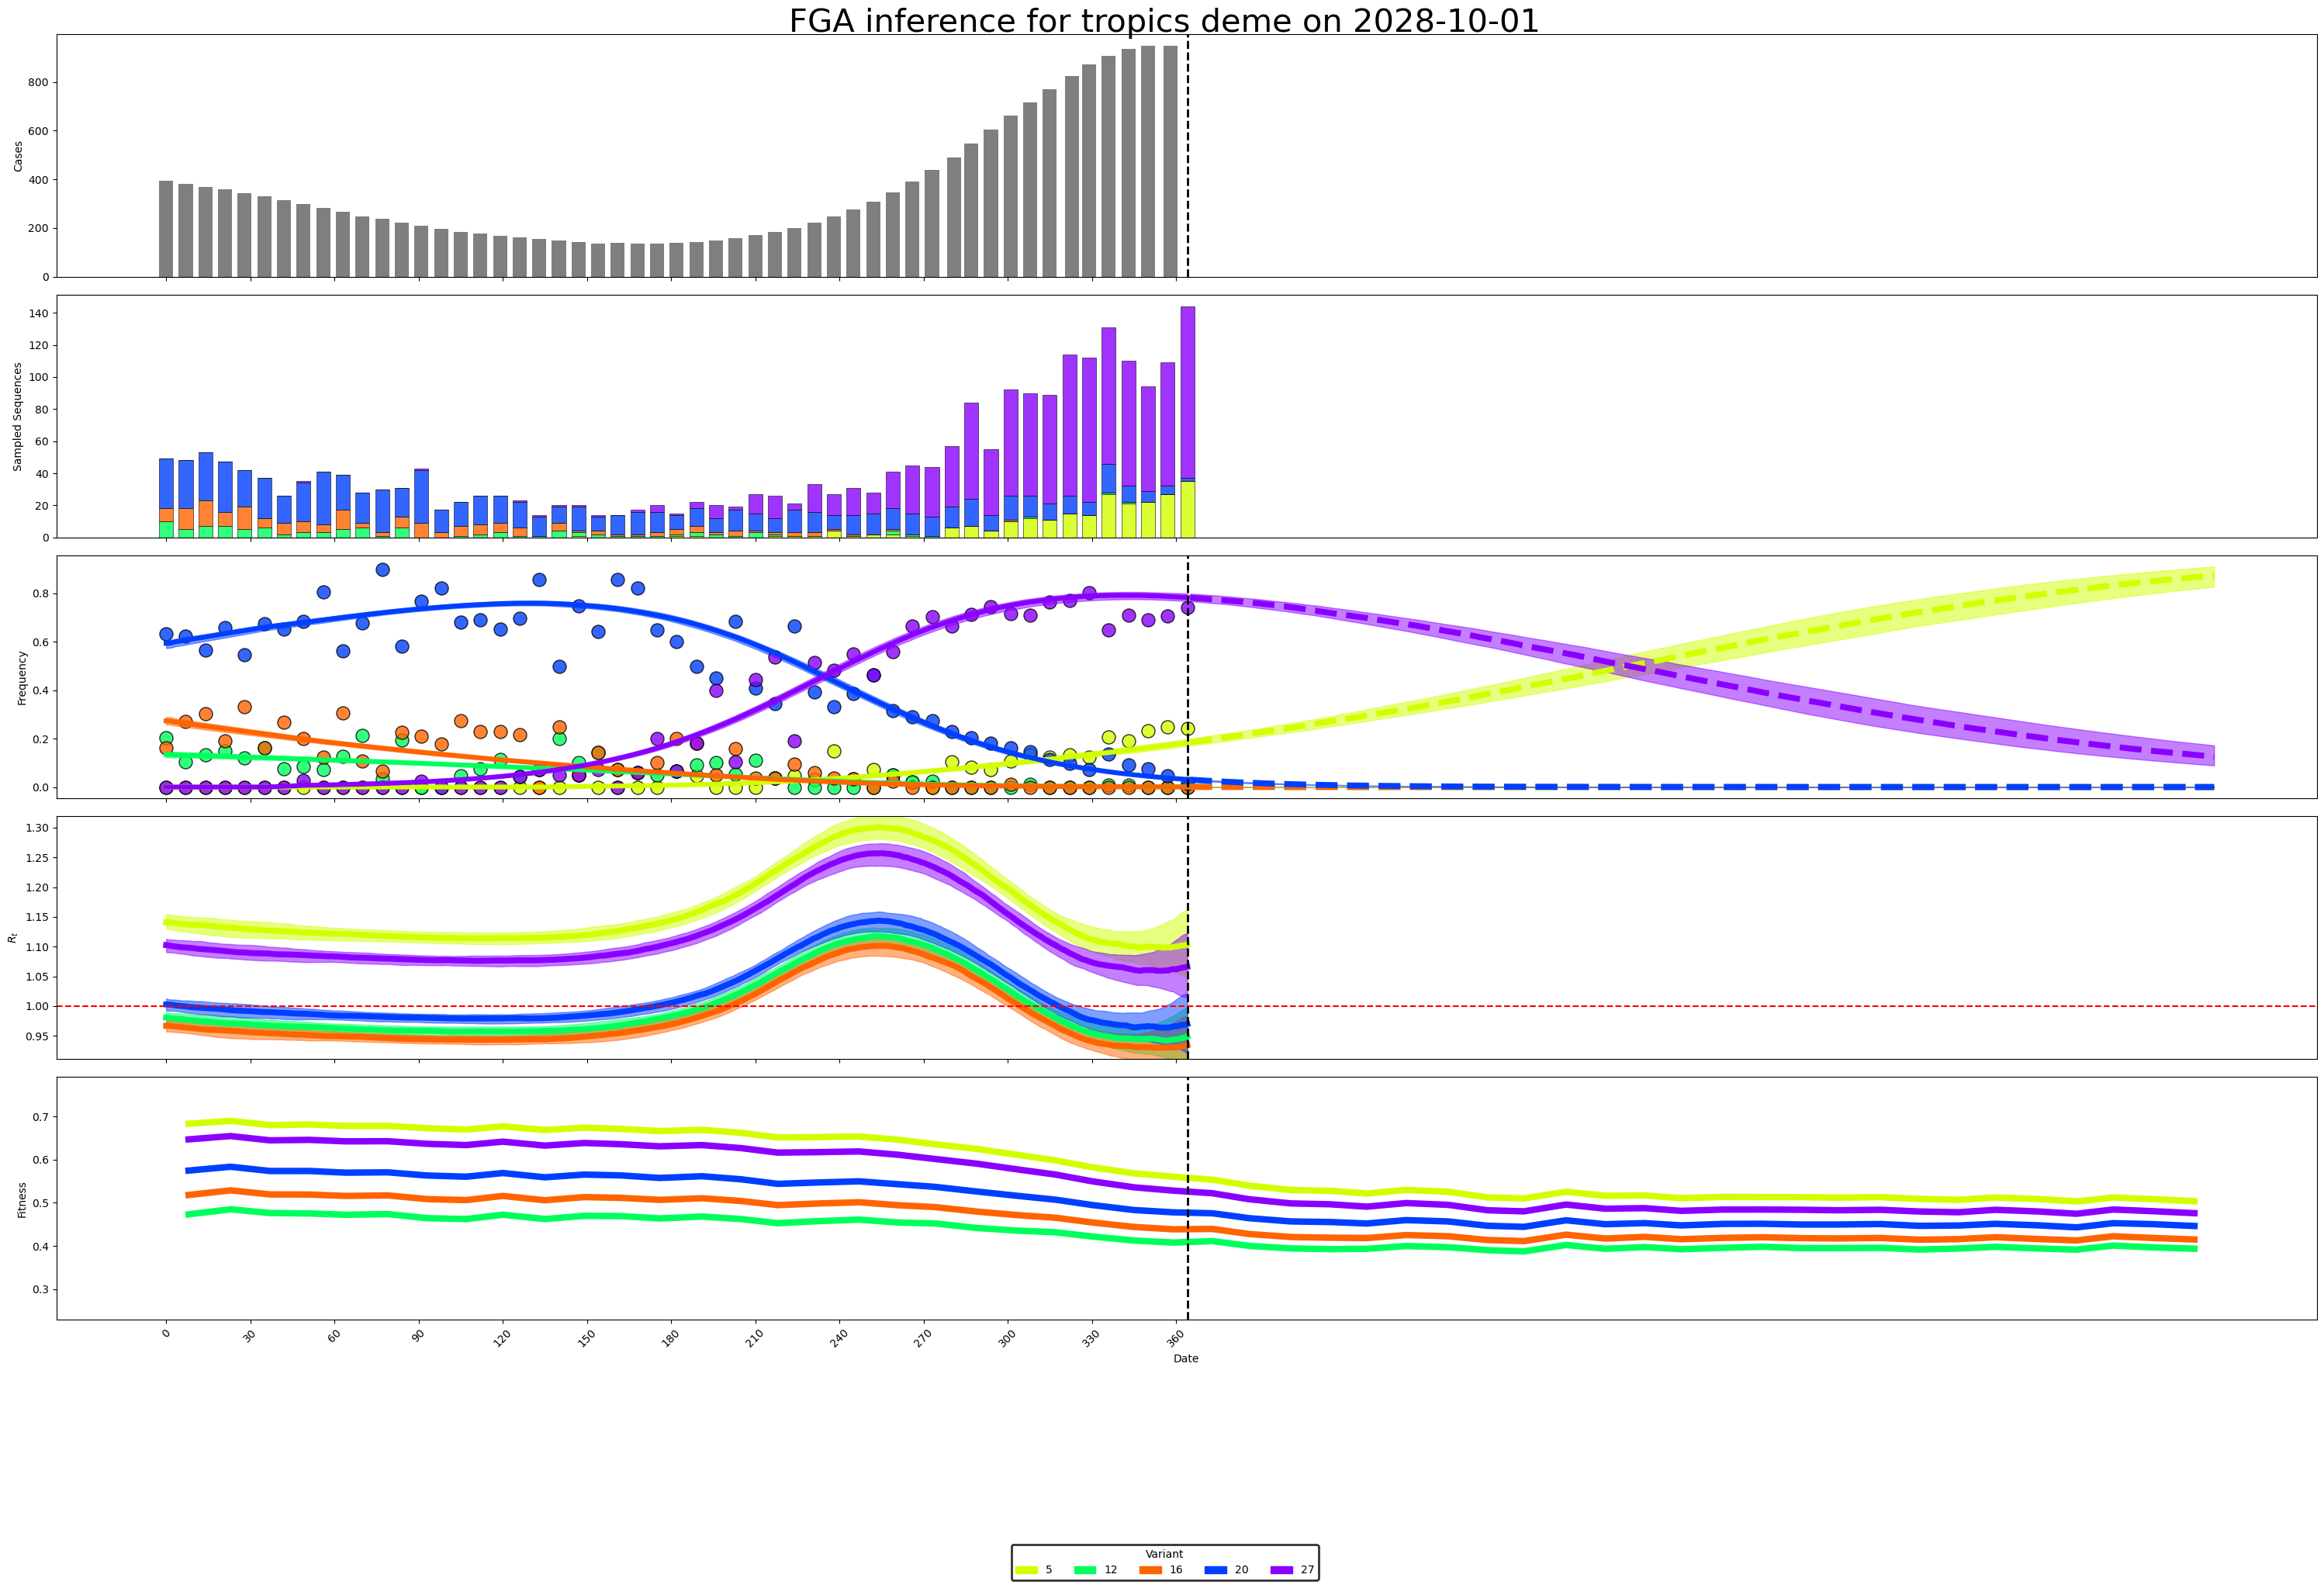

In [17]:
plot_analysis_window_with_variant_counts(
    pivot_date="2028-10-01", 
    location="tropics", 
    model="FGA", 
    build=build, 
    pruned_variant_fitness_df=fitness_df, 
    color_map=color_map
)

## Variant growth Rate Calculations and Comparrisons using Euler-Lotka Method

I found this in Marlin's paper and did some research -- need to double check that I'm using the correct Gamma distribution in this proof below, but the process should be the same, just with different algebra

### Quick overview
The Euler-Lotka equation provides a way to calculate growth rates based on reproduction numbers and generation time distributions. This approach is particularly useful for infectious disease modeling as it connects the effective reproduction number (Rt) with the exponential growth rate (r).

In the Fixed Growth Advantage (FGA) model, each variant has its own multiplicative growth factor $\delta_v$ that scales a variant-agnostic effective reproduction number $R_t$:

$$R_v(t) = \delta_v \cdot R_t$$

The Growth Advantage Random Walk (GARW) model allows variant growth advantages to vary smoothly over time, with each variant's effective reproduction number following a random walk prior:

$$R_v(t) \sim \mathcal{N}(R_v(t-1), \sigma^2)$$

The Euler-Lotka equation establishes the relationship between the effective reproduction number ($R_v(t)$) and the exponential growth rate ($r_v(t)$) accounting for the generation time distribution. 

The equation looks like this:

$$ \int_{0}^{\infty} e^{-r\tau} R_0 g(\tau)\,d\tau = 1 $$

Where:
* $r$ is the epidemic growth rate
* $\tau$ is a possible generation time
* $R_0 g(\tau)\,d\tau$ can be interpreted as the average numebr of **new** infections caused by our initial host at generation time $\tau$ (i.e., think between a time $t$ and $t + \tau$)
* $e^{-r\tau}$ is the "discount" of new cases accumulated during the generation time (keeps us from double counting infections I believe)


### Derivation of $r_{\text{model},v}(t_i)$ for our use case
Notice that this is actually $M_g(-r)$: MGF for $g(\tau)$, evaluated at $-r$, and then multiplied by $R_0$.

So we can now re-write this as $$R_0 \cdot M_g(-r) = 1$$

$$R_0 = \frac{1}{M_g(-r)} $$

And for our $R_t$:

$$R_t = \frac{1}{M_g(-r)} $$

We have been using a gamma distribution with shape parameter $\alpha$ and scale parameter $\theta$ for generation time distribution. 
The MGF for this gamma distribution is:

$$M_g(x) = (1 - x \theta)^{-\alpha} \text{ for } x\theta < 1 $$

Evaluating for $-r`: 

$$ M_g(-r) = (1 + r \theta)^{-k\alpha}$$

And since $R_t = \frac{1}{M_g(-r)}$, we have: 

$$R_t = (1 + r\theta)^{\alpha} $$

This is essentially where Marlin's paper stops with the Gamma case...now, we'd like to get the variant growth rate $r$ -- so let's solve for that:

$$R^{1/\alpha}_t = 1 + r\theta $$

$$r = \frac{R^{1/\alpha} - 1}{\theta} $$

So now we have a relationship between $r$ and model inferred $R_t$ (let's add the t to $r$ now...)

$$r_{\text{model}}(t) = \frac{R_t^{1/\alpha} - 1}{\theta}$$

### Derivation of $r_{\text{data},v}(t_i)$ for our use case
We can then let $C_{d}(t_i)$ be the number of observed cases in location $d$ at time $t_i$.

We can calculate a smoothed growth rate estimate for the observed case counts:

$$r_{\text{data}}(t_i) = \frac{\ln(C_{d}(t_i)) - \ln(C_{d}(t_i - 1))}{\Delta t_i}  $$

If we'd like this metric to be variant-specific, we have to estimate the number of counts attributable to a variant $v$:

$$C_{v,d}(t_i) = C_d(t_i) \cdot f_{v,d}(t_i) $$

$$r_{\text{data},v}(t_i) = \frac{\ln(C_{v,d}(t_i)) - \ln(C_{v,d}(t_i - 1))}{\Delta t_i}  $$


### Big Idea

* With these two metrics in hand, we can more rigorously compare model $R_t$ inference to the variant-specific growth rates in a deme
* This allows us to side-step the mis-match of looking at the derivative of raw variant counts and comparing them to the value of Rt
* We can now calculate pearson correlation between these two things and have a clear idea of how well models are doing
* Training windows with few and/or sparse case counts may generate pretty noisy $r_{\text{data},v}(t_i)$ however
* Sequence and case counts are reported weekly, where model inference is daily, so we'll have to consolidate this a bit... we could just focus on reporting dates and ignore inference on the six days in between each one... Or possibly interpolate the rest of the week with whatever the value is for that week, etc.
* Univariate spline smoothing on variant count data since these can be a lot nosier than cases -- but maybe these should be smoothed too?

## The Relationship Between Rt and Growth Rate (r)

(This is a sanity check for Zorian) -- not important for discussion.)

The Euler-Lotka equation establishes the relationship between the effective reproduction number (Rt) and the exponential growth rate (r) accounting for the generation time distribution. For a gamma-distributed generation time with shape parameter k and scale parameter θ, the relationship is:

$$r = \frac{R_t^{1/k} - 1}{\theta}$$

Let's visualize this relationship for different parameter values.

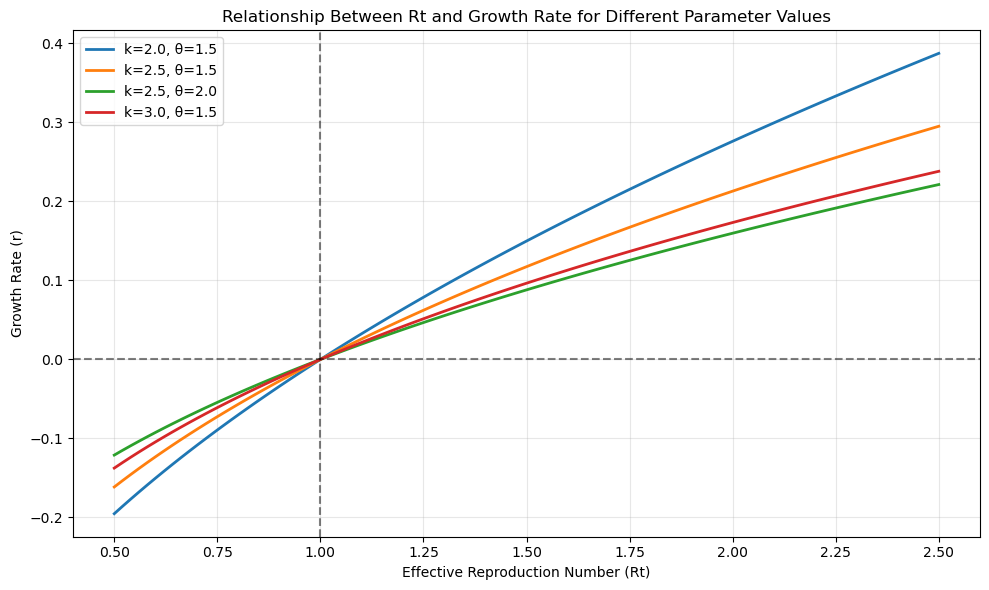

In [18]:
# Plot the relationship between Rt and r for different parameter values
Rt_values = np.linspace(0.5, 2.5, 100)

plt.figure(figsize=(10, 6))

# Define parameter sets to test
params = [
    {'shape': 2.0, 'scale': 1.5, 'label': 'k=2.0, θ=1.5'},
    {'shape': 2.5, 'scale': 1.5, 'label': 'k=2.5, θ=1.5'},
    {'shape': 2.5, 'scale': 2.0, 'label': 'k=2.5, θ=2.0'},
    {'shape': 3.0, 'scale': 1.5, 'label': 'k=3.0, θ=1.5'}
]

for i, param in enumerate(params):
    # Calculate r from Rt using the Euler-Lotka formula
    r_values = (Rt_values**(1.0/param['shape']) - 1.0) / param['scale']
    plt.plot(Rt_values, r_values, label=param['label'], linewidth=2)

plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=1, color='k', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('Effective Reproduction Number (Rt)')
plt.ylabel('Growth Rate (r)')
plt.title('Relationship Between Rt and Growth Rate for Different Parameter Values')
plt.legend()
plt.tight_layout()
plt.show()

## Calculate $r_{\text{data}}$ and $r_{\text{model}}$ on example window

In [19]:
# Load the sequence and case count data
timestamp = "2028-10-01" 
seqs_path = f"../data/{build}/time-stamped/{timestamp}/seq_counts.tsv"
cases_path = f"../data/{build}/time-stamped/{timestamp}/case_counts.tsv"
seqs_df = pd.read_csv(seqs_path, sep='\t')
cases_df = pd.read_csv(cases_path, sep='\t')

# Add week_id column to both DataFrames for weekly calculations
seqs_df = add_week_id_column(seqs_df, date_col='date')
cases_df = add_week_id_column(cases_df, date_col='date')
print(seqs_df.head())
print(cases_df.head()) 

        date  country  variant  sequences  week_id
0 2027-10-03    south       12          7        0
1 2027-10-03    south       16         40        0
2 2027-10-03    south       20         39        0
3 2027-10-03  tropics       12         10        0
4 2027-10-03  tropics       16          8        0
        date  country  cases  week_id
0 2027-10-03    north      8        0
1 2027-10-03    south    646        0
2 2027-10-03  tropics    394        0
3 2027-10-10    north      8        1
4 2027-10-10    south    463        1


In [20]:
# Take a look at some of the top variants
variant_seqs = seqs_df.groupby('variant')['sequences'].sum().sort_values(ascending=False)
top_variants = variant_seqs.head()
print("Top 5 variants by total sequences:")
print(top_variants)

# Select the first variant for demonstration
example_variant = top_variants.index[0]
example_location = 'tropics'

# Get incidence series for the example variant
variant_incidence = get_variant_incidence(seqs_df, example_location, example_variant)
print(f"\nSequence count data for variant {example_variant} in {example_location}:")
print(variant_incidence.head())

Top 5 variants by total sequences:
variant
27    1224
20    1043
16     318
5      251
12     120
Name: sequences, dtype: int64

Sequence count data for variant 27 in tropics:
date
2027-11-21    1
2028-01-02    1
2028-02-06    1
2028-02-13    1
2028-02-20    1
dtype: int64


## Converting Model Rt Values to Theoretical Growth Rates

Using the Euler-Lotka equation, we can convert the model-estimated Rt values to theoretical growth rates (r). This allows us to compare model-derived growth rates with empirically estimated growth rates from sequence data.

In [21]:
# Load Rt values for a specific model and location
rt_df = load_model_rt_values(build, 'FGA', 'tropics', '2028-10-01')
rt_df.head()

Loaded 3650 Rt values from ../results/flu-simulated-150k-samples/estimates/FGA/rt_tropics_2028-10-01.tsv


,date,location,variant,median_R,R_upper_95,R_lower_95,R_upper_80,R_lower_80,R_upper_50,R_lower_50,model,analysis_date
0,2027-10-03,tropics,12,0.980604,1.008204,0.951036,0.999150,0.962058,0.989919,0.970341,FGA,2028-10-01
1,2027-10-04,tropics,12,0.979902,1.007786,0.952345,0.997826,0.962321,0.988813,0.969696,FGA,2028-10-01
2,2027-10-05,tropics,12,0.979431,1.006897,0.951802,0.996956,0.962506,0.988103,0.969224,FGA,2028-10-01
3,2027-10-06,tropics,12,0.979128,1.006026,0.951854,0.996654,0.961515,0.987997,0.968957,FGA,2028-10-01
4,2027-10-07,tropics,12,0.978486,1.005749,0.950903,0.996461,0.960966,0.987873,0.968154,FGA,2028-10-01


In [22]:
# These are the parameters used in the generation time distribution when fitting models with `evofr`
gamma_mean = 3.1
gamma_std = 1.0

In [23]:
# Calculate the shape and scale parameters for the gamma distribution
alpha, theta = get_gamma_distribution_params(gamma_mean, gamma_std)

In [24]:
# Now calculate growth rates from the loaded Rt values
rt_df = convert_rt_to_growth_rate(rt_df, gamma_shape=alpha, gamma_scale=theta)
rt_df.head()

,date,location,variant,median_R,R_upper_95,R_lower_95,R_upper_80,R_lower_80,R_upper_50,R_lower_50,model,analysis_date,growth_rate_r
0,2027-10-03,tropics,12,0.980604,1.008204,0.951036,0.999150,0.962058,0.989919,0.970341,FGA,2028-10-01,-0.006312
1,2027-10-04,tropics,12,0.979902,1.007786,0.952345,0.997826,0.962321,0.988813,0.969696,FGA,2028-10-01,-0.006542
2,2027-10-05,tropics,12,0.979431,1.006897,0.951802,0.996956,0.962506,0.988103,0.969224,FGA,2028-10-01,-0.006697
3,2027-10-06,tropics,12,0.979128,1.006026,0.951854,0.996654,0.961515,0.987997,0.968957,FGA,2028-10-01,-0.006797
4,2027-10-07,tropics,12,0.978486,1.005749,0.950903,0.996461,0.960966,0.987873,0.968154,FGA,2028-10-01,-0.007008


In [ ]:
# Add variant frequencies to the smoothed sequence counts (to experiment with frequency-based r_data)
smoothed_seqs_df = smooth_sequences_with_spline(seqs_df, s=0.5, k=3)
smoothed_seqs_df = add_variant_frequencies(smoothed_seqs_df, count_column='smoothed_sequences')
growth_rates_df_freqs = calculate_variant_growth_rates(seqs_df=smoothed_seqs_df, cases_df=cases_df, use_freqs=True)
try:
    growth_rates_df_freqs['date'] = growth_rates_df_freqs['date'].dt.strftime('%Y-%m-%d')
except AttributeError:
    # If 'date' is not a datetime object, convert it to string format
    growth_rates_df_freqs['date'] = pd.to_datetime(growth_rates_df_freqs['date']).dt.strftime('%Y-%m-%d')
# Merge with the frequencies data
growth_rates_df_freqs = pd.merge(
    growth_rates_df_freqs, 
    rt_df[['date', 'variant', 'growth_rate_r', 'model', 'analysis_date']], 
    on=['date', 'variant'], 
    how='left', 
    suffixes=('', '_model')
).drop_duplicates()

In [118]:
# Smooth the sequence counts using spline fitting
smoothed_seqs_df = smooth_sequences_with_spline(seqs_df, s=5, k=3)
smoothed_seqs_df = add_variant_frequencies(smoothed_seqs_df, count_column='smoothed_sequences')

# Calculate growth rates based on the smoothed counts
growth_rates_df = calculate_variant_growth_rates(seqs_df=smoothed_seqs_df, cases_df=cases_df, use_freqs=False)

try:
    # Change date column to string format for merging
    growth_rates_df['date'] = growth_rates_df['date'].dt.strftime('%Y-%m-%d')
    rt_df['date'] = rt_df['date'].dt.strftime('%Y-%m-%d')
except AttributeError:
    # If date is already a string, do nothing
    pass
# Merge with the model data for comparison
growth_rates_df = pd.merge(
    growth_rates_df, 
    rt_df[['date', 'variant', 'growth_rate_r', 'model', 'analysis_date']], 
    on=['date', 'variant'], 
    how='left', 
    suffixes=('', '_model')
).drop_duplicates()



   country       date  freq_sum
32   north 2028-07-09       0.0


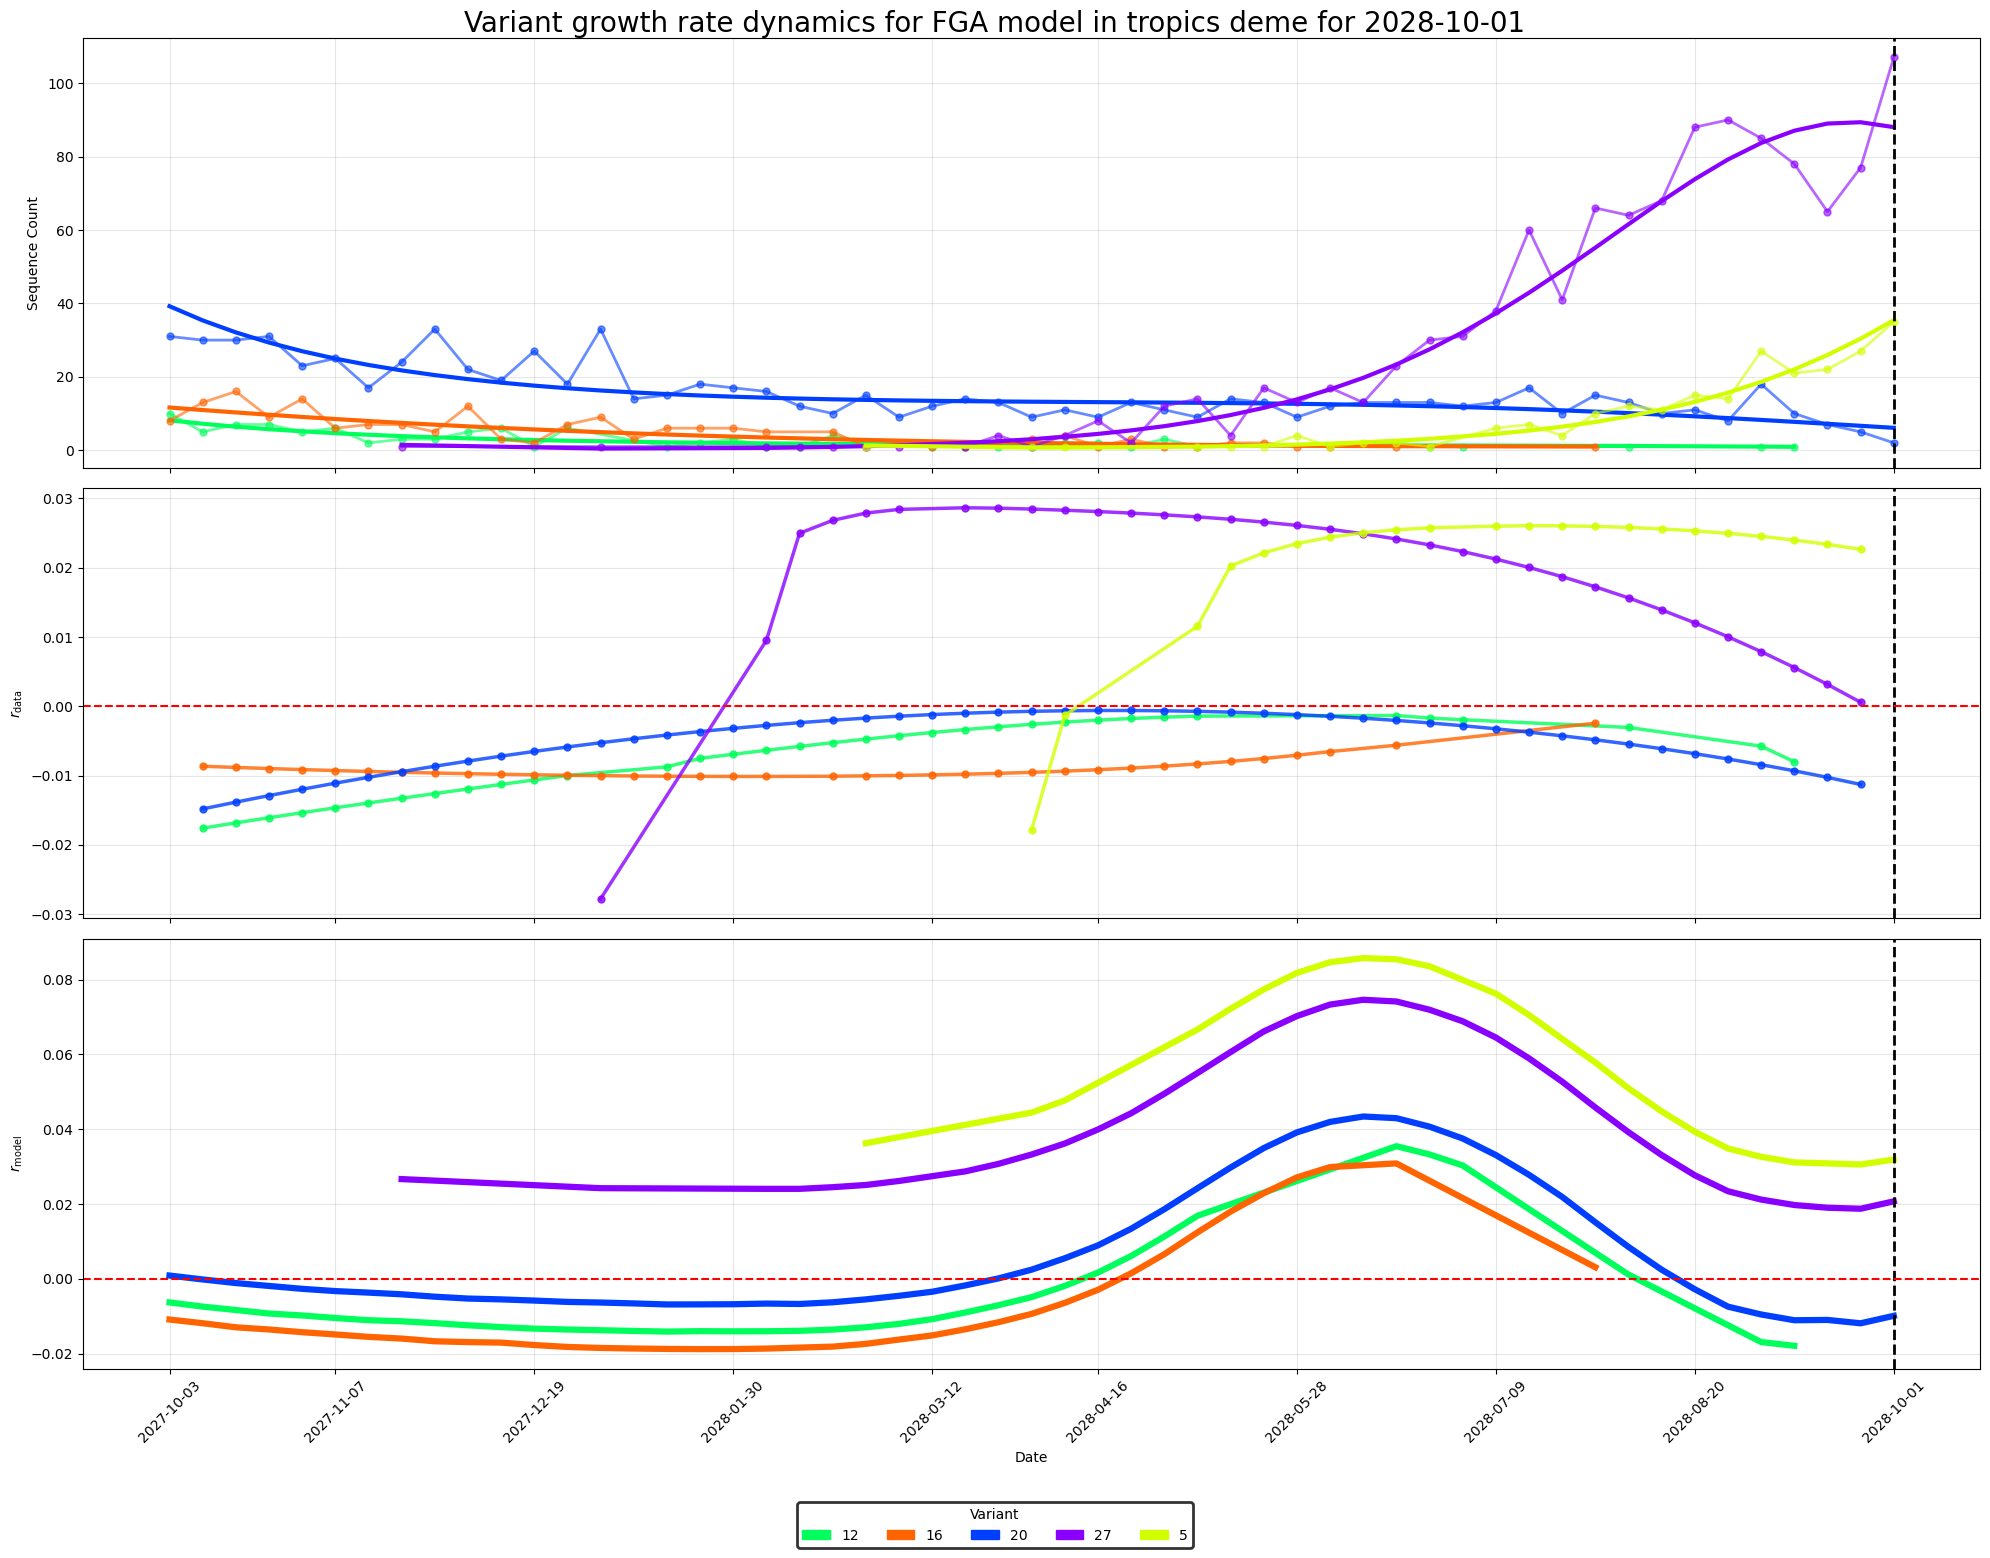

In [119]:
plot_growth_rate_dynamics(
    growth_rates_df=growth_rates_df, 
    location='tropics', 
    r_data_col='growth_rate_r_data',
    analysis_date=timestamp,
    color_map=color_map
)

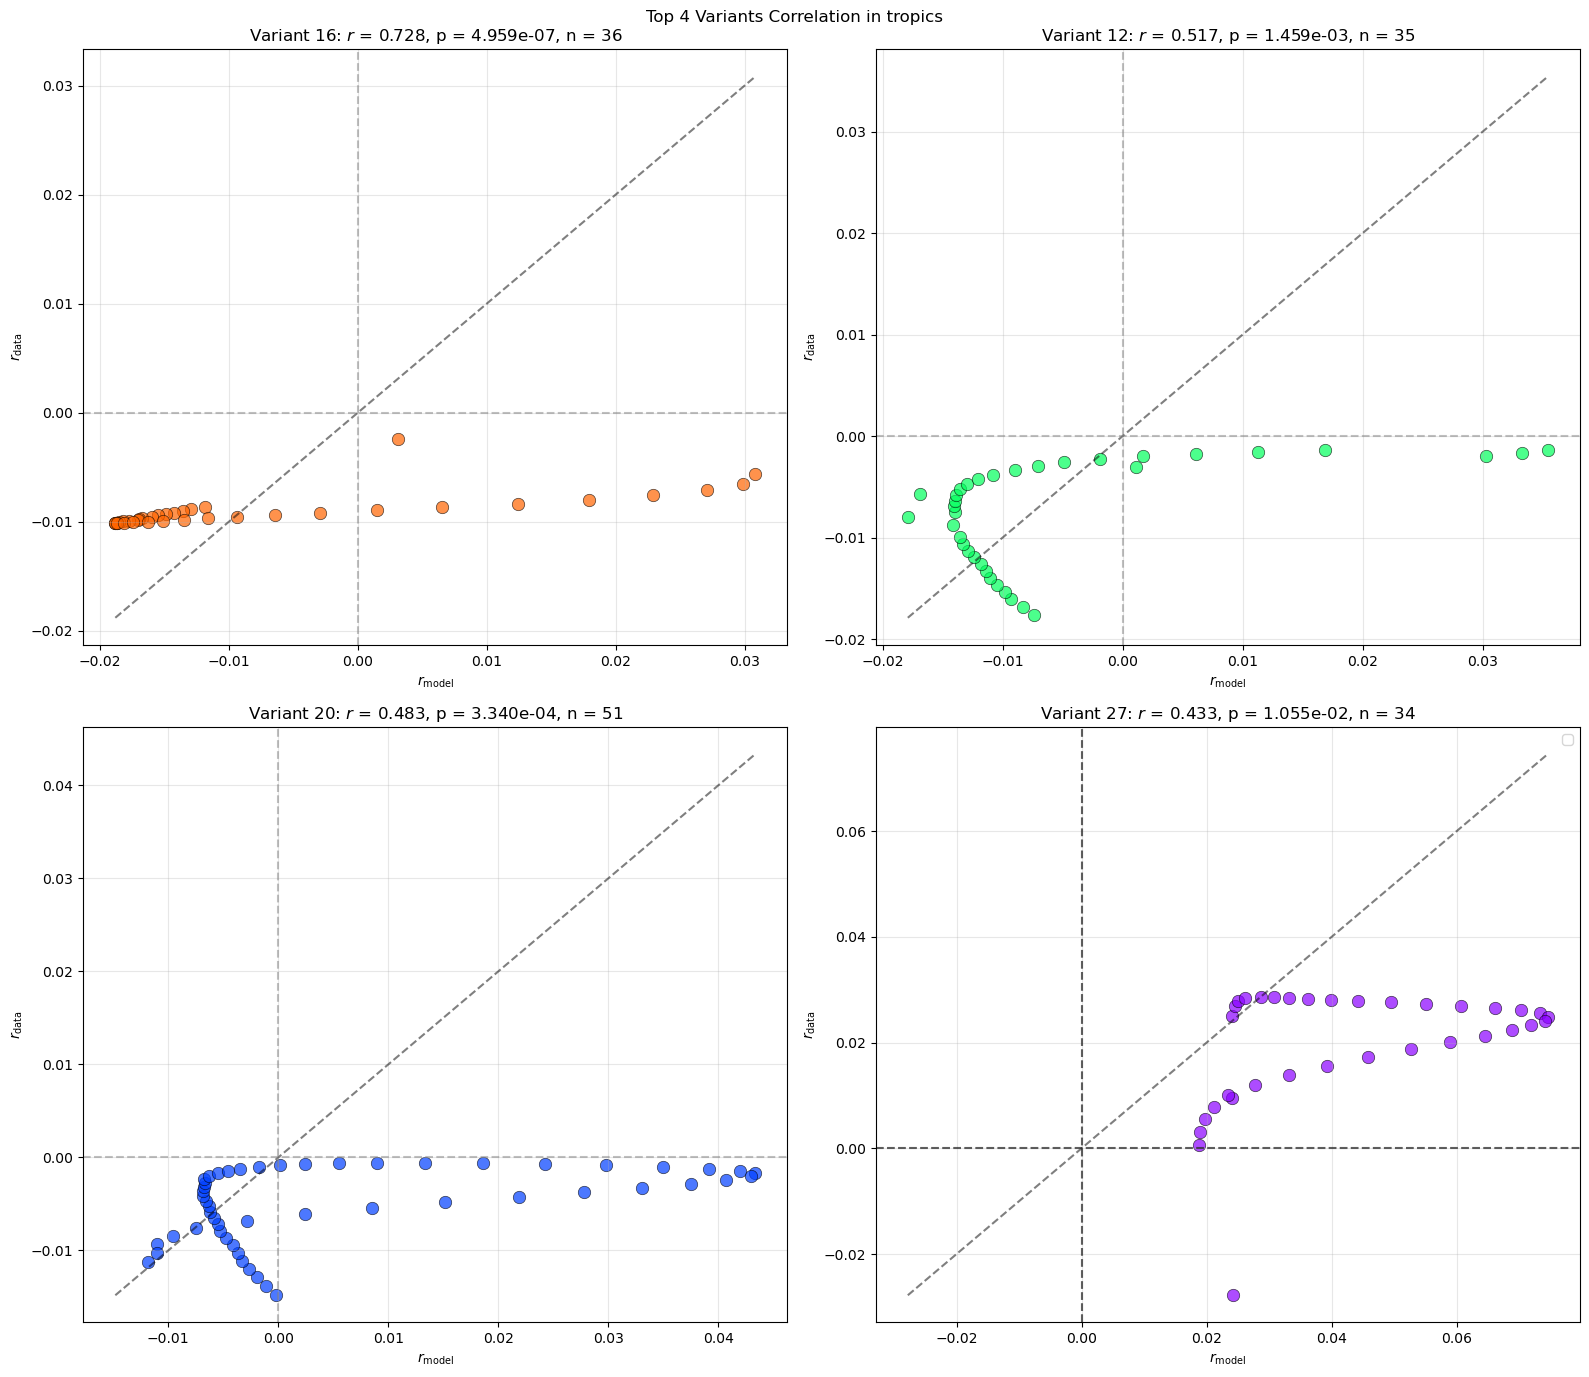

In [120]:
plot_top_variant_correlations(
    growth_rates_df=growth_rates_df, 
    location='tropics', 
    n=4, 
    min_points=3, 
    r_model_col='growth_rate_r',  
    r_data_col='growth_rate_r_data'
)

* r_model doesn't seem to be any different from the types of issues we saw with Rt -- which was expected
* ~~r_data however, seems to actually capture the derivative of variant counts -- they should be smoothed but I'm not sure why they look so spiky...~~
* ~~As seen below, while there isn't a great correlation with these metrics -- due to the noisy r_data trajectories, however, it does seem like these metrics agree with each other more qualitatively than the fitness metric (at least in this example)~~
* ~~A way to get smoother r_data trajectories would be nice...~~
* Smoothed r_data trajectories do look more reasonable.

Things to do:
* Move finalized code over to `antigentools` module to de-clutter notebook
* Come up with a nice summary metric for this analysis on all data sets
* ~~Add some context about why we've started moving to this growth-rate based approach for benchmarking Rt~~
* ~~Refine/edit math explanations above and plots~~
* ~~Share notebook link with John~~